# Preprocessing: Natural Stories & Dundee Corpora

This notebook loads, cleans, and explores both datasets used in the project.

- **Natural Stories Corpus** — primary dataset for all main analyses (self-paced reading; 180 subjects, 10 stories)
- **Dundee Corpus** — verification/replication dataset for robustness checks (eye-tracking fixation data; 10 subjects, 20 newspaper texts)

In [1]:
import os, re, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Paths
BASE     = os.path.dirname(os.getcwd())   # notebooks/ -> project root
DATA_NS  = os.path.join(BASE, "data", "natural_stories")
DATA_DUN = os.path.join(BASE, "data", "dundee", "dundee")
OUT_NS   = os.path.join(BASE, "data", "natural_stories")
OUT_DUN  = os.path.join(BASE, "data", "dundee")

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="muted")
print("Paths OK.")
print("  BASE    :", BASE)
print("  DATA_NS :", DATA_NS)
print("  DATA_DUN:", DATA_DUN)

Paths OK.
  BASE    : c:\Users\mudit\OneDrive\Desktop\Fourth Sem\computational-psycholinguistics\Project
  DATA_NS : c:\Users\mudit\OneDrive\Desktop\Fourth Sem\computational-psycholinguistics\Project\data\natural_stories
  DATA_DUN: c:\Users\mudit\OneDrive\Desktop\Fourth Sem\computational-psycholinguistics\Project\data\dundee\dundee


---\n## Part 1: Natural Stories Corpus

In [2]:
# ── 1.1 Load raw reading times ─────────────────────────────────────────────────
rt_path = os.path.join(DATA_NS, "naturalstories_RTS", "processed_RTs.tsv")
rts_raw = pd.read_csv(rt_path, sep="\t")
rts_raw = rts_raw.rename(columns={
    "WorkerId": "subject", "item": "story",
    "zone": "zone", "RT": "RT", "word": "word", "correct": "correct"
})[["subject", "story", "zone", "word", "RT", "correct"]]

print("Shape:", rts_raw.shape)
print(f"Subjects : {rts_raw['subject'].nunique()}")
print(f"Stories  : {rts_raw['story'].nunique()}")
print(f"Zones    : {rts_raw['zone'].nunique()}")
print(f"RT range : {rts_raw['RT'].min()} ms  -  {rts_raw['RT'].max()} ms")
print()
rts_raw.head(10)

Shape: (848875, 6)
Subjects : 180
Stories  : 10
Zones    : 1099
RT range : 101 ms  -  2992 ms



,subject,story,zone,word,RT,correct
0,A3QJPB0NZU5PY1,1,1,If,637,6
1,A2RPQGUWVZPX7U,1,1,If,1222,5
2,A11KMPAZSE5Q0Q,1,1,If,416,5
3,A1U1QL617G5DU3,1,1,If,571,6
4,ACTW5YEWV9OR0,1,1,If,1208,6
5,A1RE0RBV10VAVC,1,1,If,790,6
6,ALE5RDP8XZL3,1,1,If,597,6
7,A35QV79054LGTU,1,1,If,602,6
8,ARGHS9P7FVR3W,1,1,If,470,6
9,A2TG01V56PAL65,1,1,If,1547,5


In [3]:
# ── 1.2 Per-story trial counts and subject coverage ───────────────────────────
story_stats = rts_raw.groupby("story").agg(
    trials     = ("RT", "count"),
    n_subjects = ("subject", "nunique"),
    n_zones    = ("zone", "nunique"),
    mean_RT    = ("RT", "mean"),
).reset_index()
print("Per-story statistics:")
print(story_stats.to_string(index=False))

Per-story statistics:
 story  trials  n_subjects  n_zones    mean_RT
     1   90964          90     1073 328.873071
     2   90231          94      990 337.262183
     3   94529          95     1040 341.447133
     4   95073          93     1085 342.715818
     5   94902          98     1013 328.705275
     6   90363          92     1099 329.707624
     7   74385          82      999 322.663507
     8   71178          82      980 348.425862
     9   80265          91     1038 352.770498
    10   66985          82      939 351.926581


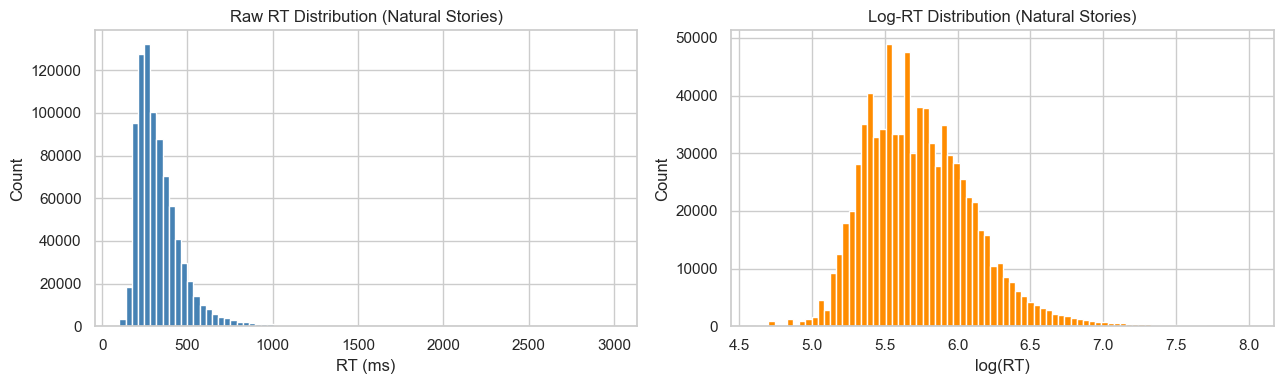

In [4]:
# ── 1.3 Raw RT distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(rts_raw["RT"], bins=80, color="steelblue", edgecolor="white")
axes[0].set_xlabel("RT (ms)")
axes[0].set_ylabel("Count")
axes[0].set_title("Raw RT Distribution (Natural Stories)")

axes[1].hist(np.log(rts_raw["RT"]), bins=80, color="darkorange", edgecolor="white")
axes[1].set_xlabel("log(RT)")
axes[1].set_ylabel("Count")
axes[1].set_title("Log-RT Distribution (Natural Stories)")

plt.tight_layout()
plt.show()

In [5]:
# ── 1.4 Clean RTs ──────────────────────────────────────────────────────────────
n_before = len(rts_raw)

# Filter: comprehension score >= 4/6
rts = rts_raw[rts_raw["correct"] >= 4].copy()
print(f"After comprehension filter (correct >= 4): {len(rts):,} / {n_before:,}  ({100*len(rts)/n_before:.1f}%)")

# RT bounds: 100 ms - 3000 ms
rts = rts[(rts["RT"] >= 100) & (rts["RT"] <= 3000)].copy()
print(f"After RT range filter (100-3000 ms)       : {len(rts):,} / {n_before:,}  ({100*len(rts)/n_before:.1f}%)")

# Log-transform
rts["log_RT"] = np.log(rts["RT"])

# Per-subject z-score of log_RT
rts["log_RT_z"] = rts.groupby("subject")["log_RT"].transform(
    lambda x: (x - x.mean()) / x.std()
)

print()
print("Cleaned RT summary:")
print(rts[["RT", "log_RT", "log_RT_z"]].describe().round(3).to_string())

After comprehension filter (correct >= 4): 848,875 / 848,875  (100.0%)
After RT range filter (100-3000 ms)       : 848,875 / 848,875  (100.0%)

Cleaned RT summary:
               RT      log_RT    log_RT_z
count  848875.000  848875.000  848875.000
mean      337.960       5.740       0.000
std       172.147       0.381       1.000
min       101.000       4.615      -8.895
25%       236.000       5.464      -0.624
50%       297.000       5.694      -0.167
75%       391.000       5.969       0.417
max      2992.000       8.004      11.993


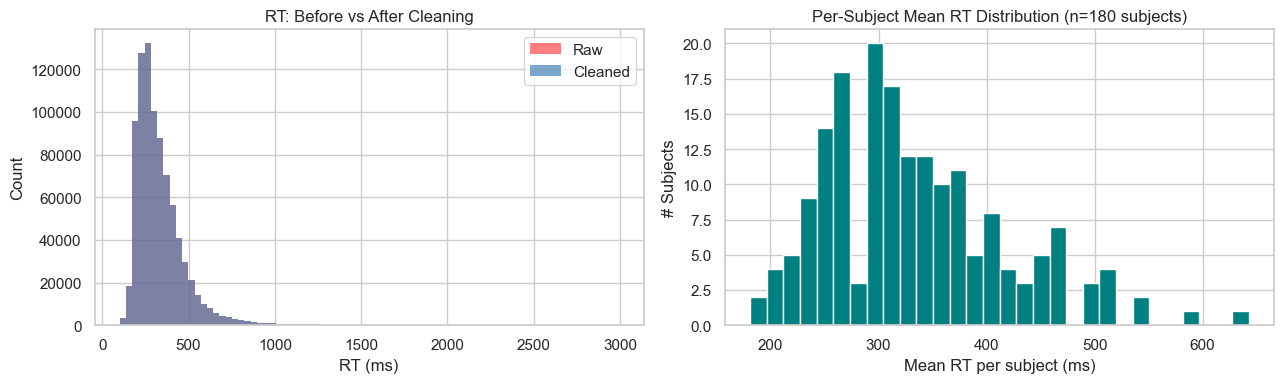

In [6]:
# ── 1.5 RT distributions before vs after cleaning ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before vs after
axes[0].hist(rts_raw["RT"], bins=80, alpha=0.5, color="red", label="Raw", edgecolor="none")
axes[0].hist(rts["RT"], bins=80, alpha=0.7, color="steelblue", label="Cleaned", edgecolor="none")
axes[0].set_xlabel("RT (ms)")
axes[0].set_ylabel("Count")
axes[0].set_title("RT: Before vs After Cleaning")
axes[0].legend()

# Per-subject mean RT boxplot
subj_means = rts.groupby("subject")["RT"].mean()
axes[1].hist(subj_means, bins=30, color="teal", edgecolor="white")
axes[1].set_xlabel("Mean RT per subject (ms)")
axes[1].set_ylabel("# Subjects")
axes[1].set_title(f"Per-Subject Mean RT Distribution (n={len(subj_means)} subjects)")

plt.tight_layout()
plt.show()

In [7]:
# ── 1.6 Load word list and aggregate by word ───────────────────────────────────
words_path = os.path.join(DATA_NS, "words.tsv")
raw_words = pd.read_csv(words_path, sep="\t", header=None, names=["key", "word_text"])
mask = raw_words["key"].str.endswith(".whole")
words_df = raw_words[mask].copy()
parts = words_df["key"].str.split(".", expand=True)
words_df["story"] = parts[0].astype(int)
words_df["zone"]  = parts[1].astype(int)
words_df = words_df[["story", "zone", "word_text"]].reset_index(drop=True)

print(f"Word list: {len(words_df):,} entries across {words_df['story'].nunique()} stories")
print()
print("Sample words (story 1, zones 1-15):")
print(words_df[words_df["story"] == 1].head(15).to_string(index=False))

Word list: 10,256 entries across 10 stories

Sample words (story 1, zones 1-15):
 story  zone word_text
     1     1        If
     1     2       you
     1     3      were
     1     4        to
     1     5   journey
     1     6        to
     1     7       the
     1     8     North
     1     9        of
     1    10 England ,
     1    11       you
     1    12     would
     1    13      come
     1    14        to
     1    15         a


In [8]:
# ── 1.7 Aggregate RTs to word level ───────────────────────────────────────────
ns_agg = rts.groupby(["story", "zone", "word"]).agg(
    mean_RT       = ("RT",       "mean"),
    mean_log_RT   = ("log_RT",   "mean"),
    mean_log_RT_z = ("log_RT_z", "mean"),
    n_subjects    = ("subject",  "nunique"),
).reset_index().rename(columns={"word": "word_text"})

# Merge with word list for clean word text, then add features
ns_agg = ns_agg.merge(words_df, on=["story", "zone"], how="left", suffixes=("_rt", ""))
ns_agg["word_clean"] = ns_agg["word_text"].str.replace(r"[^a-zA-Z'-]", "", regex=True)
ns_agg["word_len"]   = ns_agg["word_clean"].str.len()

print(f"Word-level aggregated rows: {len(ns_agg):,}")
print()
print("Sample:")
print(ns_agg[["story","zone","word_text","mean_RT","mean_log_RT","mean_log_RT_z","n_subjects","word_len"]].head(15).to_string(index=False))

Word-level aggregated rows: 10,256

Sample:
 story  zone word_text    mean_RT  mean_log_RT  mean_log_RT_z  n_subjects  word_len
     1     1        If 578.964286     6.268741       2.052692          84         2
     1     2       you 369.011905     5.830609       0.378104          84         3
     1     3      were 368.183908     5.828199       0.355197          87         4
     1     4        to 344.318182     5.737662       0.017462          88         2
     1     5   journey 354.639535     5.722561      -0.008469          86         7
     1     6        to 349.674157     5.755698       0.104182          89         2
     1     7       the 376.370787     5.768338       0.099895          89         3
     1     8     North 327.310345     5.695342      -0.118665          87         5
     1     9        of 365.494382     5.731538      -0.016314          89         2
     1    10 England , 344.931034     5.727129       0.007523          87         7
     1    11       you 400.26966

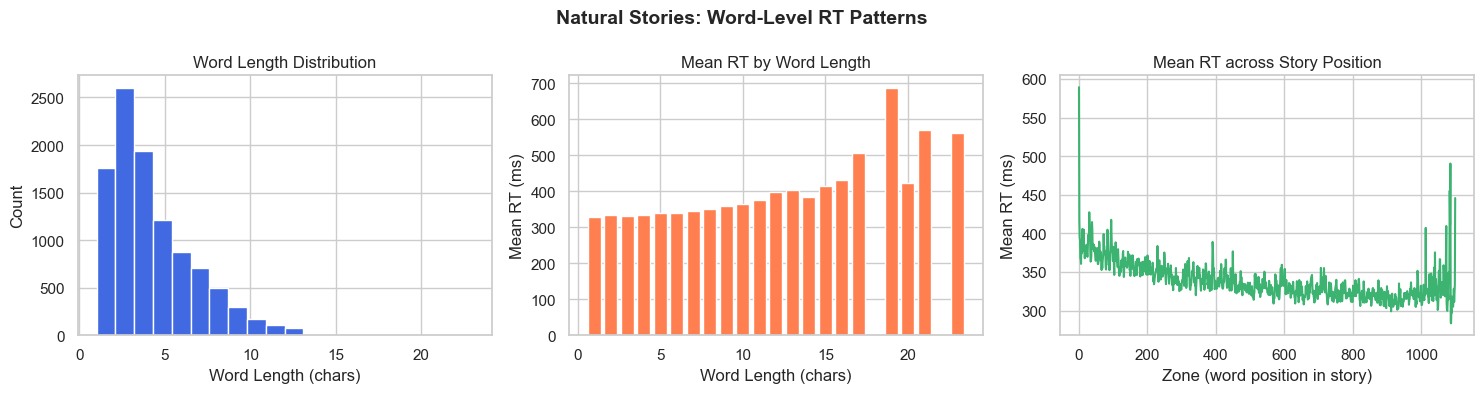

In [9]:
# ── 1.8 Word-level analyses ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Word length distribution
axes[0].hist(ns_agg["word_len"].dropna(), bins=20, color="royalblue", edgecolor="white")
axes[0].set_xlabel("Word Length (chars)")
axes[0].set_ylabel("Count")
axes[0].set_title("Word Length Distribution")

# Mean RT by word length
wl_rt = ns_agg.groupby("word_len")["mean_RT"].mean().reset_index()
axes[1].bar(wl_rt["word_len"], wl_rt["mean_RT"], color="coral")
axes[1].set_xlabel("Word Length (chars)")
axes[1].set_ylabel("Mean RT (ms)")
axes[1].set_title("Mean RT by Word Length")

# Mean RT by sentence position (zone)
pos_rt = ns_agg.groupby("zone")["mean_RT"].mean().reset_index()
axes[2].plot(pos_rt["zone"], pos_rt["mean_RT"], color="mediumseagreen", linewidth=1.5)
axes[2].set_xlabel("Zone (word position in story)")
axes[2].set_ylabel("Mean RT (ms)")
axes[2].set_title("Mean RT across Story Position")

plt.suptitle("Natural Stories: Word-Level RT Patterns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
# ── 1.9 Save NS outputs ────────────────────────────────────────────────────────
rts.to_csv(os.path.join(OUT_NS, "ns_clean.csv"), index=False)
words_df.to_csv(os.path.join(OUT_NS, "ns_words.csv"), index=False)
ns_agg.to_csv(os.path.join(OUT_NS, "ns_word_agg.csv"), index=False)
print("Saved:")
print("  ns_clean.csv    :", len(rts), "rows")
print("  ns_words.csv    :", len(words_df), "rows")
print("  ns_word_agg.csv :", len(ns_agg), "rows")

Saved:
  ns_clean.csv    : 848875 rows
  ns_words.csv    : 10256 rows
  ns_word_agg.csv : 10256 rows


---\n## Part 2: Dundee Corpus

In [11]:
# ── 2.1 Parse all subject files ───────────────────────────────────────────────
import glob

SUBJECT_COLS = ["WORD", "TEXT", "LINE", "OLEN", "WLEN",
                "XPOS", "WNUM", "FDUR", "OBLP", "WDLP", "LAUN", "TXFR"]

def parse_subject_file(path):
    fname = os.path.basename(path)
    m = re.match(r"s([a-z])(\d{2})ma(\d)p\.dat", fname)
    if not m:
        return []
    subject, text_num, pass_num = m.group(1), int(m.group(2)), int(m.group(3))
    rows = []
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if i == 0:
                continue
            parts = line.split()
            if not parts or parts[0].startswith("*"):
                continue
            try:
                if len(parts) < 12:
                    continue
                rows.append({
                    "subject": subject, "text_num": text_num, "pass_num": pass_num,
                    "word": parts[0],
                    "TEXT": int(parts[1]), "LINE": int(parts[2]),
                    "OLEN": int(parts[3]), "WLEN": int(parts[4]),
                    "XPOS": int(parts[5]), "WNUM": int(parts[6]),
                    "FDUR": int(parts[7]), "OBLP": int(parts[8]),
                    "WDLP": int(parts[9]), "LAUN": int(parts[10]),
                    "TXFR": int(parts[11]),
                })
            except (ValueError, IndexError):
                continue
    return rows

dun_files = sorted(glob.glob(os.path.join(DATA_DUN, "s*.dat")))
print(f"Subject files found: {len(dun_files)}")

all_rows = []
for path in dun_files:
    all_rows.extend(parse_subject_file(path))

fix_raw = pd.DataFrame(all_rows)
print(f"Total raw fixation rows: {len(fix_raw):,}")
print(f"Subjects: {fix_raw['subject'].nunique()}  |  Texts: {fix_raw['text_num'].nunique()}  |  Passes: {fix_raw['pass_num'].unique()}")
fix_raw.head(8)

Subject files found: 400
Total raw fixation rows: 1,026,128
Subjects: 10  |  Texts: 20  |  Passes: [1 2]


,subject,text_num,pass_num,word,TEXT,LINE,OLEN,WLEN,XPOS,WNUM,FDUR,OBLP,WDLP,LAUN,TXFR
0,a,1,1,Are,1,1,3,3,1,1,216,1,1,0,351
1,a,1,1,tourists,1,1,8,8,6,2,156,2,2,-5,3
2,a,1,1,enticed,1,1,7,7,17,3,227,4,4,-11,1
3,a,1,1,these,1,1,5,5,25,5,187,1,1,-8,73
4,a,1,1,attractions,1,1,11,11,33,6,182,3,3,-8,2
5,a,1,1,threatening,1,1,11,11,44,7,96,2,2,-11,3
6,a,1,1,threatening,1,1,11,11,52,7,232,10,10,-99,3
7,a,1,1,very,1,1,4,4,62,9,335,2,2,-10,56


FDUR value counts (pass 1 vs pass 2):
             count    mean     std  min    25%    50%    75%     max
pass_num                                                            
1         411145.0  196.10   82.96  0.0  148.0  190.0  236.0  2851.0
2         614983.0  130.73  114.53  0.0    0.0  148.0  210.0  2851.0


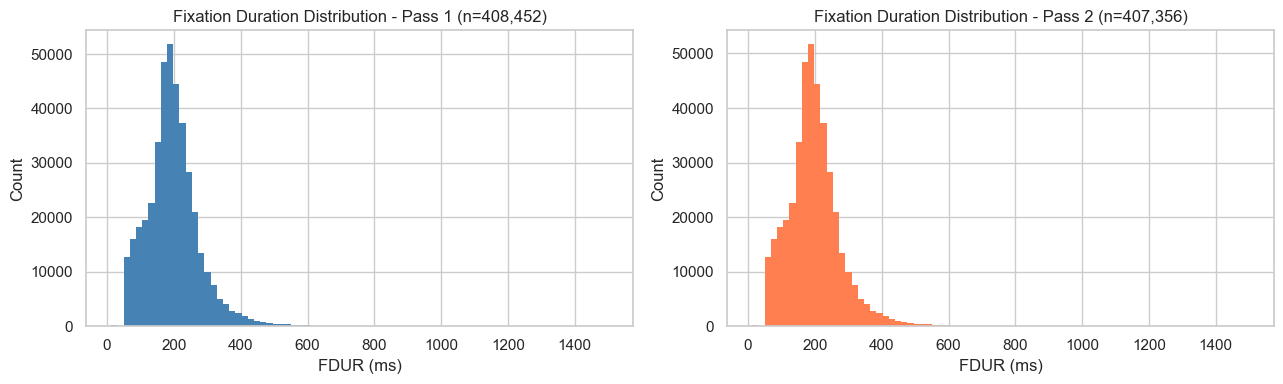

In [12]:
# ── 2.2 FDUR distribution by pass ─────────────────────────────────────────────
print("FDUR value counts (pass 1 vs pass 2):")
print(fix_raw.groupby("pass_num")["FDUR"].describe().round(2).to_string())

valid = fix_raw[fix_raw["FDUR"] > 0]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, pass_n, color in zip(axes, [1, 2], ["steelblue", "coral"]):
    subset = valid[valid["pass_num"] == pass_n]["FDUR"]
    ax.hist(subset.clip(upper=1500), bins=80, color=color, edgecolor="none")
    ax.set_xlabel("FDUR (ms)")
    ax.set_ylabel("Count")
    ax.set_title(f"Fixation Duration Distribution - Pass {pass_n} (n={len(subset):,})")

plt.tight_layout()
plt.show()

In [13]:
# ── 2.3 Clean: first-pass only, FDUR 50-1200 ms, deduplicate ─────────────────
n_raw = len(fix_raw)

fix = fix_raw[fix_raw["pass_num"] == 1].copy()
print(f"Pass 1 only             : {len(fix):,} / {n_raw:,}")

fix = fix[fix["FDUR"] > 0].copy()
print(f"FDUR > 0 (remove blinks): {len(fix):,}")

fix = fix[(fix["FDUR"] >= 50) & (fix["FDUR"] <= 1200)].copy()
print(f"50 <= FDUR <= 1200 ms   : {len(fix):,}")

fix = fix.sort_values(["subject", "text_num", "WNUM"])
fix = fix.drop_duplicates(subset=["subject", "text_num", "WNUM"], keep="first")
print(f"After dedup (first fix per word): {len(fix):,}")

fix["log_FDUR"] = np.log(fix["FDUR"])
fix["log_FDUR_z"] = fix.groupby("subject")["log_FDUR"].transform(
    lambda x: (x - x.mean()) / x.std()
)

print()
print("Cleaned FDUR summary:")
print(fix[["FDUR", "log_FDUR", "log_FDUR_z"]].describe().round(3).to_string())

Pass 1 only             : 411,145 / 1,026,128
FDUR > 0 (remove blinks): 408,452
50 <= FDUR <= 1200 ms   : 408,050
After dedup (first fix per word): 307,582

Cleaned FDUR summary:
             FDUR    log_FDUR  log_FDUR_z
count  307582.000  307582.000  307582.000
mean      202.308       5.235      -0.000
std        77.826       0.400       1.000
min        50.000       3.912      -4.504
25%       158.000       5.063      -0.484
50%       195.000       5.273       0.087
75%       239.000       5.476       0.621
max      1142.000       7.041       4.711


In [14]:
# ── 2.4 Load Dundee text metadata ─────────────────────────────────────────────
def load_text_file(path):
    fname = os.path.basename(path)
    m = re.match(r"tx(\d{2})wrdp\.dat", fname)
    if not m:
        return []
    text_num = int(m.group(1))
    rows = []
    with open(path, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 14:
                continue
            try:
                rows.append({
                    "text_num":        text_num,
                    "WNUM":            int(parts[12]),
                    "word_text":       parts[0],
                    "wpos_in_line":    int(parts[4]),
                    "line_num":        int(parts[5]),
                    "olen":            int(parts[7]),
                    "wlen":            int(parts[8]),
                    "punct_before":    int(parts[9]),
                    "punct_after":     int(parts[10]),
                    "word_freq_class": int(parts[13].strip()),
                })
            except (ValueError, IndexError):
                continue
    return rows

tx_files = sorted(glob.glob(os.path.join(DATA_DUN, "tx*.dat")))
txt_rows = []
for p in tx_files:
    txt_rows.extend(load_text_file(p))
txt_df = pd.DataFrame(txt_rows)

print(f"Text file rows: {len(txt_df):,} across {txt_df['text_num'].nunique()} texts")
print()
print("Sample from text 1:")
print(txt_df[txt_df["text_num"] == 1].head(10).to_string(index=False))

Text file rows: 51,501 across 20 texts

Sample from text 1:
 text_num  WNUM   word_text  wpos_in_line  line_num  olen  wlen  punct_before  punct_after  word_freq_class
        1     1         Are             1         1     3     3             0            0              351
        1     2    tourists             2         2     8     8             0            0                3
        1     3     enticed             3         3     7     7             0            0                1
        1     4          by             4         4     2     2             0            0              252
        1     5       these             5         5     5     5             0            0               73
        1     6 attractions             6         6    11    11             0            0                2
        1     7 threatening             7         7    11    11             0            0                3
        1     8       their             8         8     5     5             

In [15]:
# ── 2.5 Merge fixations with text metadata ────────────────────────────────────
txt_key = txt_df[["text_num", "WNUM", "word_text", "wlen", "punct_before",
                  "punct_after", "word_freq_class", "line_num", "wpos_in_line"]]
dun = fix.merge(txt_key, on=["text_num", "WNUM"], how="left")
print(f"After merge: {len(dun):,} rows")
print(f"Matched word_text: {dun['word_text'].notna().sum():,} / {len(dun):,}")
print()
dun.head(8)

After merge: 307,582 rows
Matched word_text: 307,571 / 307,582



,subject,text_num,pass_num,word,TEXT,LINE,OLEN,WLEN,XPOS,WNUM,FDUR,OBLP,WDLP,LAUN,TXFR,log_FDUR,log_FDUR_z,word_text,wlen,punct_before,punct_after,word_freq_class,line_num,wpos_in_line
0,a,1,1,Are,1,1,3,3,1,1,216,1,1,0,351,5.375278,0.269375,Are,3.0,0.0,0.0,351.0,1.0,1.0
1,a,1,1,tourists,1,1,8,8,6,2,156,2,2,-5,3,5.049856,-0.806840,tourists,8.0,0.0,0.0,3.0,2.0,2.0
2,a,1,1,enticed,1,1,7,7,17,3,227,4,4,-11,1,5.424950,0.433645,enticed,7.0,0.0,0.0,1.0,3.0,3.0
3,a,1,1,these,1,1,5,5,25,5,187,1,1,-8,73,5.231109,-0.207414,these,5.0,0.0,0.0,73.0,5.0,5.0
4,a,1,1,attractions,1,1,11,11,33,6,182,3,3,-8,2,5.204007,-0.297044,attractions,11.0,0.0,0.0,2.0,6.0,6.0
5,a,1,1,threatening,1,1,11,11,44,7,96,2,2,-11,3,4.564348,-2.412479,threatening,11.0,0.0,0.0,3.0,7.0,7.0
6,a,1,1,their,1,1,5,5,57,8,168,3,3,5,225,5.123964,-0.561755,their,5.0,0.0,0.0,225.0,8.0,8.0
7,a,1,1,very,1,1,4,4,62,9,335,2,2,-10,56,5.814131,1.720717,very,4.0,0.0,0.0,56.0,9.0,9.0


In [16]:
# ── 2.6 Aggregate to word level ───────────────────────────────────────────────
dun_agg = dun.groupby(["text_num", "WNUM", "word_text"]).agg(
    mean_FDUR        = ("FDUR",            "mean"),
    mean_log_FDUR    = ("log_FDUR",        "mean"),
    mean_log_FDUR_z  = ("log_FDUR_z",      "mean"),
    n_subjects       = ("subject",         "nunique"),
    word_len         = ("wlen",            "first"),
    line_num         = ("line_num",        "first"),
    wpos_in_line     = ("wpos_in_line",    "first"),
    word_freq_class  = ("word_freq_class", "first"),
).reset_index()

print(f"Word-level aggregated rows: {len(dun_agg):,}")
print()
print("Sample:")
print(dun_agg.head(12).to_string(index=False))

Word-level aggregated rows: 50,650

Sample:
 text_num  WNUM   word_text  mean_FDUR  mean_log_FDUR  mean_log_FDUR_z  n_subjects  word_len  line_num  wpos_in_line  word_freq_class
        1     1         Are 154.285714       5.006451        -0.732279           7       3.0       1.0           1.0            351.0
        1     2    tourists 173.600000       5.122610        -0.367107          10       8.0       2.0           2.0              3.0
        1     3     enticed 227.200000       5.350754         0.298543          10       7.0       3.0           3.0              1.0
        1     4          by 207.285714       5.302052         0.109256           7       2.0       4.0           4.0            252.0
        1     5       these 173.900000       5.140666        -0.237526          10       5.0       5.0           5.0             73.0
        1     6 attractions 213.000000       5.304290         0.128312          10      11.0       6.0           6.0              2.0
        1     7 th

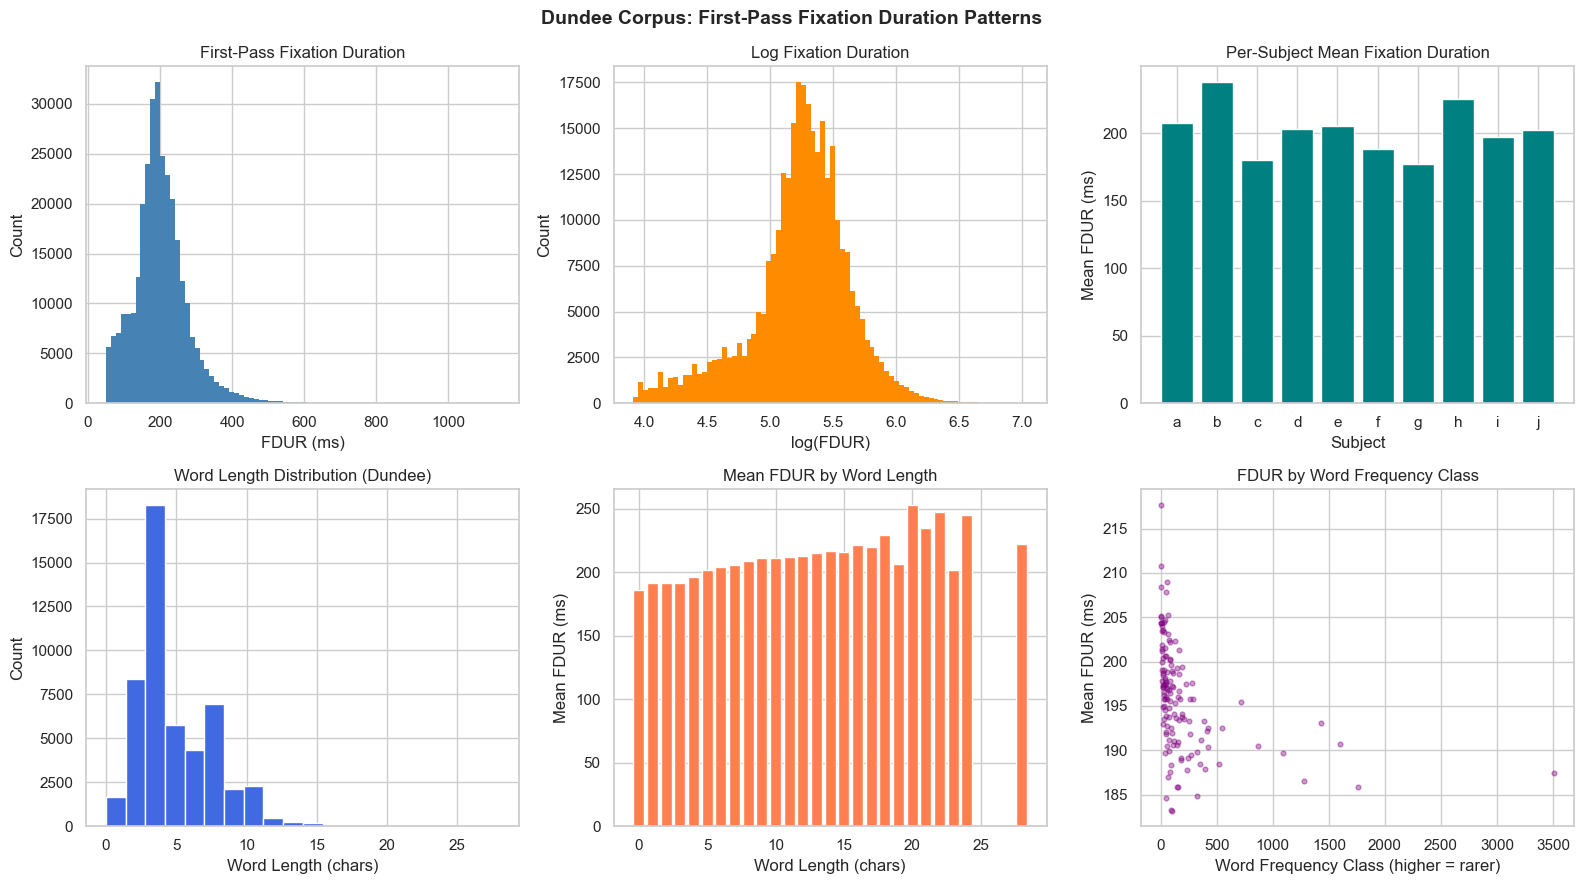

In [17]:
# ── 2.7 Dundee word-level analyses ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# FDUR distribution (cleaned)
axes[0,0].hist(dun["FDUR"], bins=80, color="steelblue", edgecolor="none")
axes[0,0].set_xlabel("FDUR (ms)")
axes[0,0].set_ylabel("Count")
axes[0,0].set_title("First-Pass Fixation Duration")

# Log FDUR
axes[0,1].hist(dun["log_FDUR"], bins=80, color="darkorange", edgecolor="none")
axes[0,1].set_xlabel("log(FDUR)")
axes[0,1].set_ylabel("Count")
axes[0,1].set_title("Log Fixation Duration")

# Per-subject mean FDUR
subj_means_dun = dun.groupby("subject")["FDUR"].mean()
axes[0,2].bar(subj_means_dun.index, subj_means_dun.values, color="teal")
axes[0,2].set_xlabel("Subject")
axes[0,2].set_ylabel("Mean FDUR (ms)")
axes[0,2].set_title("Per-Subject Mean Fixation Duration")

# Word length distribution
axes[1,0].hist(dun_agg["word_len"].dropna(), bins=20, color="royalblue", edgecolor="white")
axes[1,0].set_xlabel("Word Length (chars)")
axes[1,0].set_ylabel("Count")
axes[1,0].set_title("Word Length Distribution (Dundee)")

# Mean FDUR by word length
wl_fdur = dun_agg.groupby("word_len")["mean_FDUR"].mean().reset_index().dropna()
axes[1,1].bar(wl_fdur["word_len"], wl_fdur["mean_FDUR"], color="coral")
axes[1,1].set_xlabel("Word Length (chars)")
axes[1,1].set_ylabel("Mean FDUR (ms)")
axes[1,1].set_title("Mean FDUR by Word Length")

# Mean FDUR by word frequency class
wf_fdur = dun_agg.groupby("word_freq_class")["mean_FDUR"].mean().reset_index().dropna()
wf_fdur = wf_fdur[wf_fdur["word_freq_class"] > 0]
axes[1,2].scatter(wf_fdur["word_freq_class"], wf_fdur["mean_FDUR"],
                  alpha=0.4, s=12, color="purple")
axes[1,2].set_xlabel("Word Frequency Class (higher = rarer)")
axes[1,2].set_ylabel("Mean FDUR (ms)")
axes[1,2].set_title("FDUR by Word Frequency Class")

plt.suptitle("Dundee Corpus: First-Pass Fixation Duration Patterns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
# ── 2.8 Save Dundee outputs ────────────────────────────────────────────────────
dun.to_csv(os.path.join(OUT_DUN, "dundee_clean.csv"), index=False)
dun_agg.to_csv(os.path.join(OUT_DUN, "dundee_word_agg.csv"), index=False)
print("Saved:")
print("  dundee_clean.csv    :", len(dun), "rows")
print("  dundee_word_agg.csv :", len(dun_agg), "rows")

Saved:
  dundee_clean.csv    : 307582 rows
  dundee_word_agg.csv : 50650 rows


---\n## Part 3: Dataset Summary Comparison

In [21]:
# ── 3.1 Side-by-side summary table ────────────────────────────────────────────
summary = pd.DataFrame({
    "Property":        ["Role in project", "Corpus type", "Subjects", "Texts", "Total word tokens (unique)", 
                        "Total trials (cleaned)", "DV", "DV range", "Mean DV"],
    "Natural Stories": ["Primary dataset", "Self-paced reading", rts["subject"].nunique(), "10 stories",
                        f"{len(words_df):,}", f"{len(rts):,}", "RT (ms)",
                        f"{rts['RT'].min()} - {rts['RT'].max()} ms",
                        f"{rts['RT'].mean():.1f} ms"],
    "Dundee":          ["Verification / replication dataset", "Eye-tracking", fix["subject"].nunique(), "20 newspaper texts",
                        f"{len(dun_agg):,}", f"{len(dun):,}", "Fixation Duration (ms)",
                        f"{dun['FDUR'].min()} - {dun['FDUR'].max()} ms",
                        f"{dun['FDUR'].mean():.1f} ms"],
})
print(summary.to_string(index=False))

                  Property    Natural Stories                             Dundee
           Role in project    Primary dataset Verification / replication dataset
               Corpus type Self-paced reading                       Eye-tracking
                  Subjects                180                                 10
                     Texts         10 stories                 20 newspaper texts
Total word tokens (unique)             10,256                             50,650
    Total trials (cleaned)            848,875                            307,582
                        DV            RT (ms)             Fixation Duration (ms)
                  DV range      101 - 2992 ms                       50 - 1142 ms
                   Mean DV           338.0 ms                           202.3 ms


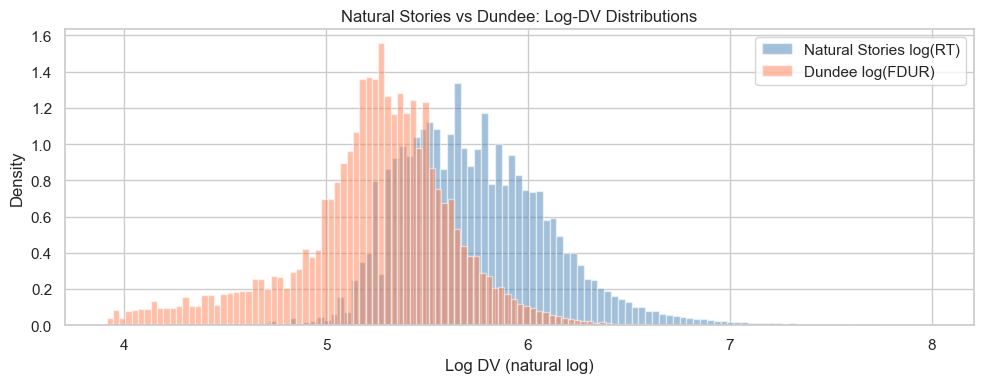

Natural Stories  mean log_RT  : 5.7403
Dundee           mean log_FDUR: 5.2351


In [20]:
# ── 3.2 Overlay: log-DV distributions from both corpora ───────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(rts["log_RT"],       bins=100, density=True, alpha=0.5, color="steelblue", label="Natural Stories log(RT)")
ax.hist(dun["log_FDUR"],     bins=100, density=True, alpha=0.5, color="coral",     label="Dundee log(FDUR)")
ax.set_xlabel("Log DV (natural log)")
ax.set_ylabel("Density")
ax.set_title("Natural Stories vs Dundee: Log-DV Distributions")
ax.legend()
plt.tight_layout()
plt.show()

print("Natural Stories  mean log_RT  :", rts["log_RT"].mean().round(4))
print("Dundee           mean log_FDUR:", dun["log_FDUR"].mean().round(4))